# Compare z-slab vs ray-traced flux (batch outputs)

Both methods use the **same FV geometry** as `gsimple_raytrace.ipynb` (imported from
`raytrace_volume_defs.py`): cathode gap $10<|x|<190$, and for `FV_split_truncY` a
z-dependent $y$ limit ($|y|<190$ for $10<z<250$ cm, $-190<y<100$ for $250<z<450$ cm).

| Method | Script | NPZ |
|--------|--------|-----|
| **z-slab** (several $\Delta z$) | `gsimple_batch.py` | `slab_zconfig_flux_histograms.npz` |
| **raytrace** | `gsimple_raytrace_batch.py` | `raytrace_flux_histograms.npz` |

Run `run_gsimple.sh` and `run_raytrace.sh` on the **same** `*.root` file list before using
this notebook. Check `processed_files.txt` under each output directory (see below).


In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use("../numucc_1p0pi/presentation.mplstyle")
except OSError:
    pass

from raytrace_volume_defs import RAYTRACE_VOLUME_LABEL, RAYTRACE_VOLUME_DEFS

FLAVORS = ["nue", "nuebar", "numu", "numubar"]
FLAVOR_LATEX = {
    "nue": r"$\nu_e$",
    "nuebar": r"$\bar{\nu}_e$",
    "numu": r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
}

GSIMPLE_BATCH_DIR = Path("/exp/sbnd/data/users/munjung/flux/SBND_gsimple")
RAYTRACE_BATCH_DIR = Path("/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace")

SLAB_ZCONFIG_NPZ = GSIMPLE_BATCH_DIR / "slab_zconfig_flux_histograms.npz"
SLAB_ZCONFIG_META = GSIMPLE_BATCH_DIR / "slab_zconfig_flux_histograms_meta.json"
RAYTRACE_NPZ = RAYTRACE_BATCH_DIR / "raytrace_flux_histograms.npz"
RAYTRACE_META = RAYTRACE_BATCH_DIR / "raytrace_flux_histograms_meta.json"

# Optional: raytrace written alongside gsimple_batch (same POT / files as slab npz)
RAYTRACE_NPZ_PAIRED = GSIMPLE_BATCH_DIR / "raytrace_flux_histograms.npz"

# Default slab config for single-spectrum comparison (change as needed)
DEFAULT_SLAB_CONFIG_KEY = "z10_450_n51"


## Load outputs


In [2]:
def _read_meta(path: Path) -> dict | None:
    return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else None


def _compare_volume_meta(meta_z: dict | None) -> list[dict]:
    """Per-volume slab geometry from slab_zconfig meta (matches raytrace boxes)."""
    if meta_z and "compare_volume_definitions" in meta_z:
        return meta_z["compare_volume_definitions"]
    return [
        {
            "raytrace_volume_key": v,
            "z_range_cm": [10.0, 450.0],
            "boxes_cm": [
                {
                    "x_range": list(b["x_range"]),
                    "y_range": list(b["y_range"]),
                    "z_range": list(b["z_range"]),
                }
                for b in boxes
            ],
        }
        for v, boxes in RAYTRACE_VOLUME_DEFS
    ]


def load_slab_zconfig(path: Path, config_key: str | None = None) -> dict:
    if not path.is_file():
        raise FileNotFoundError(
            f"{path} not found. Re-run gsimple_batch.py (see run_gsimple.sh)."
        )
    b = np.load(path, allow_pickle=True)
    config_keys = [str(k) for k in b["slab_config_keys"]]
    compare_vol_keys = [str(k) for k in b["compare_volume_keys"]]
    phi_cvwf = b["flux_density_mean_cvwf"]  # (n_config, n_compare_vol, n_flavor, n_E)

    if config_key is None:
        icfg = int(np.argmax(b["slab_config_n_z"]))  # finest uniform grid by default
        config_key = config_keys[icfg]
    else:
        icfg = config_keys.index(config_key)

    meta_path = path.parent / "slab_zconfig_flux_histograms_meta.json"
    meta_z = _read_meta(meta_path)
    vol_meta = _compare_volume_meta(meta_z)

    return {
        "label": f"z-slab ({config_key})",
        "method": "slab",
        "config_key": config_key,
        "icfg": icfg,
        "phi": phi_cvwf[icfg],
        "vol_keys": compare_vol_keys,
        "vol_meta": vol_meta,
        "vol_cm3": None,
        "pot": float(b["total_pot"]),
        "bins": np.asarray(b["BIN_CENTERS"]),
        "config_keys": config_keys,
        "phi_all_configs": phi_cvwf,
        "slab_config_n_z": np.asarray(b["slab_config_n_z"]),
        "slab_config_dz_cm": np.asarray(b["slab_config_dz_cm"]),
        "slab_config_batch_default": np.asarray(b["slab_config_batch_default"]),
        "meta": meta_z,
    }


def load_raytrace(path: Path) -> dict:
    if not path.is_file():
        raise FileNotFoundError(path)
    b = np.load(path, allow_pickle=True)
    if "flux_density_wvf" in b.files:
        phi = b["flux_density_wvf"]
        vol_keys = list(b["volume_keys"])
        vol_cm3 = np.asarray(b["volume_cm3"])
    elif "flux_density_raytrace_wvf" in b.files:
        phi = b["flux_density_raytrace_wvf"]
        vol_keys = list(b["raytrace_volume_keys"])
        vol_cm3 = np.asarray(b["raytrace_volume_cm3"])
    else:
        raise KeyError(f"{path.name}: no raytrace flux arrays")
    meta_path = path.parent / "raytrace_flux_histograms_meta.json"
    return {
        "label": f"raytrace ({path.name})",
        "method": "raytrace",
        "phi": phi,
        "vol_keys": vol_keys,
        "vol_cm3": vol_cm3,
        "pot": float(b["total_pot"]),
        "bins": np.asarray(b["BIN_CENTERS"]),
        "meta": _read_meta(meta_path),
        "path": path,
    }


def _load_processed_set(path: Path) -> set[str]:
    if not path.is_file():
        return set()
    return {ln.strip() for ln in path.read_text(encoding="utf-8").splitlines() if ln.strip()}


def check_same_input_files(slab_dir: Path, ray_dir: Path) -> dict:
    """Compare processed_files.txt between batch output directories."""
    proc_slab = slab_dir / "processed_files.txt"
    proc_ray = ray_dir / "processed_files.txt"
    set_slab = _load_processed_set(proc_slab)
    set_ray = _load_processed_set(proc_ray)
    only_slab = sorted(set_slab - set_ray)
    only_ray = sorted(set_ray - set_slab)
    return {
        "proc_slab": proc_slab,
        "proc_ray": proc_ray,
        "n_slab": len(set_slab),
        "n_ray": len(set_ray),
        "identical": set_slab == set_ray and len(set_slab) > 0,
        "only_slab": only_slab,
        "only_ray": only_ray,
    }


slab = load_slab_zconfig(SLAB_ZCONFIG_NPZ, DEFAULT_SLAB_CONFIG_KEY)
ray = load_raytrace(RAYTRACE_NPZ)
file_check = check_same_input_files(GSIMPLE_BATCH_DIR, RAYTRACE_BATCH_DIR)

print("SLAB:", slab["label"], "@", SLAB_ZCONFIG_NPZ.resolve())
print("  configs:", slab["config_keys"])
print("  POT", slab["pot"], "| volumes", slab["vol_keys"], "| phi", slab["phi"].shape)
print("RAY:", ray["label"], "@", RAYTRACE_NPZ.resolve())
print("  POT", ray["pot"], "| volumes", ray["vol_keys"], "| phi", ray["phi"].shape)
assert slab["vol_keys"] == ray["vol_keys"], (slab["vol_keys"], ray["vol_keys"])

print("\nInput files:")
print(f"  slab batch: {file_check['n_slab']} paths in {file_check['proc_slab'].name}")
print(f"  ray batch:  {file_check['n_ray']} paths in {file_check['proc_ray'].name}")
print(f"  identical:  {file_check['identical']}")
if not file_check["identical"]:
    print(f"  only in slab ({len(file_check['only_slab'])}):", file_check["only_slab"][:3], "...")
    print(f"  only in ray  ({len(file_check['only_ray'])}):", file_check["only_ray"][:3], "...")


SLAB: z-slab (z10_450_n51) @ /exp/sbnd/data/users/munjung/flux/SBND_gsimple/slab_zconfig_flux_histograms.npz
  configs: ['z10_450_n5', 'z10_450_n11', 'z10_450_n21', 'z10_450_n26', 'z10_450_n51', 'z10_450_n101', 'z10_450_n201', 'z0_500_n26_batch']
  POT 50000164197.1396 | volumes ['FV_split', 'FV_split_truncY'] | phi (2, 4, 80)
RAY: raytrace (raytrace_flux_histograms.npz) @ /exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/raytrace_flux_histograms.npz
  POT 50000164197.1396 | volumes ['FV_split', 'FV_split_truncY'] | phi (2, 4, 80)

Input files:
  slab batch: 5000 paths in processed_files.txt
  ray batch:  5000 paths in processed_files.txt
  identical:  True


## Metadata and POT


In [3]:
def _meta_summary(meta: dict | None, keys: list[str]) -> dict:
    if meta is None:
        return {}
    return {k: meta[k] for k in keys if k in meta}


meta_slab = slab.get("meta") or _read_meta(GSIMPLE_BATCH_DIR / "flux_histograms_meta.json")
meta_ray = ray.get("meta") or _read_meta(RAYTRACE_META)
meta_z = slab.get("meta")

if meta_slab:
    print("gsimple_batch:", _meta_summary(meta_slab, ["n_files_ok", "n_skipped", "batch_size"]))
if meta_ray:
    print("raytrace_batch:", _meta_summary(meta_ray, ["n_files_ok", "n_skipped", "batch_size"]))
if meta_z:
    print("slab z-config volumes:")
    for d in meta_z.get("compare_volume_definitions", []):
        print(f"  {d['raytrace_volume_key']}: z in {d['z_range_cm']} cm, {len(d.get('boxes_cm', []))} boxes")

pot_match = np.isclose(slab["pot"], ray["pot"], rtol=1e-9, atol=0)
print(f"\nTOTAL_POT match: {pot_match}  (slab={slab['pot']:.12g}, ray={ray['pot']:.12g})")
if not pot_match:
    print("  WARNING: different POT — re-run both batches on the same file list.")

if not file_check["identical"]:
    print("\nWARNING: processed_files differ — comparisons may be misleading.")
elif file_check["n_slab"] == 0:
    print("\nWARNING: no processed_files.txt found in one or both output dirs.")

# Optional cross-check: raytrace npz co-produced by gsimple_batch (same files/POT)
if RAYTRACE_NPZ_PAIRED.is_file():
    ray_paired = load_raytrace(RAYTRACE_NPZ_PAIRED)
    pot_paired = np.isclose(slab["pot"], ray_paired["pot"], rtol=1e-9, atol=0)
    print(f"\nPaired raytrace @ gsimple dir: POT match slab={pot_paired}")
    if pot_paired:
        for iv, vkey in enumerate(slab["vol_keys"]):
            for iflav, flav in enumerate(FLAVORS):
                pr = ray["phi"][iv, iflav]
                pp = ray_paired["phi"][iv, iflav]
                if not np.allclose(pr, pp, rtol=1e-5, atol=0):
                    print(f"  {vkey}/{flav}: dedicated ray batch != paired npz (re-run raytrace?)")
                    break


gsimple_batch: {'n_files_ok': 5000, 'batch_size': 500}
raytrace_batch: {'n_files_ok': 5000, 'n_skipped': 0, 'batch_size': 500}
slab z-config volumes:
  FV_split: z in [10.0, 450.0] cm, 2 boxes
  FV_split_truncY: z in [10.0, 450.0] cm, 4 boxes

TOTAL_POT match: True  (slab=50000164197.1, ray=50000164197.1)

Paired raytrace @ gsimple dir: POT match slab=True


## Numerical comparison (shape / ratio)


In [4]:
assert slab["vol_keys"] == ray["vol_keys"]
np.testing.assert_allclose(slab["bins"], ray["bins"], rtol=0, atol=0)

results = []
for iv, vkey in enumerate(slab["vol_keys"]):
    for iflav, flav in enumerate(FLAVORS):
        ps, pr = slab["phi"][iv, iflav], ray["phi"][iv, iflav]
        ratio = np.where(pr > 0, ps / pr, np.nan)
        valid = np.isfinite(ratio) & (pr > 0)
        med_ratio = float(np.nanmedian(ratio[valid])) if np.any(valid) else np.nan
        max_abs = float(np.nanmax(np.abs(ps - pr)))
        results.append((vkey, flav, med_ratio, max_abs))
        print(
            f"{vkey:18s} {flav:8s}  median(slab/ray)={med_ratio:8.4f}  max|diff|={max_abs:.3e}"
        )


FV_split           nue       median(slab/ray)=  0.9998  max|diff|=7.194e-09
FV_split           nuebar    median(slab/ray)=  0.9999  max|diff|=2.513e-09
FV_split           numu      median(slab/ray)=  0.9999  max|diff|=4.819e-07
FV_split           numubar   median(slab/ray)=  0.9999  max|diff|=4.662e-07
FV_split_truncY    nue       median(slab/ray)=  0.9979  max|diff|=7.000e-09
FV_split_truncY    nuebar    median(slab/ray)=  0.9973  max|diff|=2.509e-09
FV_split_truncY    numu      median(slab/ray)=  0.9974  max|diff|=4.738e-07
FV_split_truncY    numubar   median(slab/ray)=  0.9993  max|diff|=4.596e-07


## Overlay plots

Top: slab (solid) vs raytrace (dashed). Bottom: ratio slab/ray.


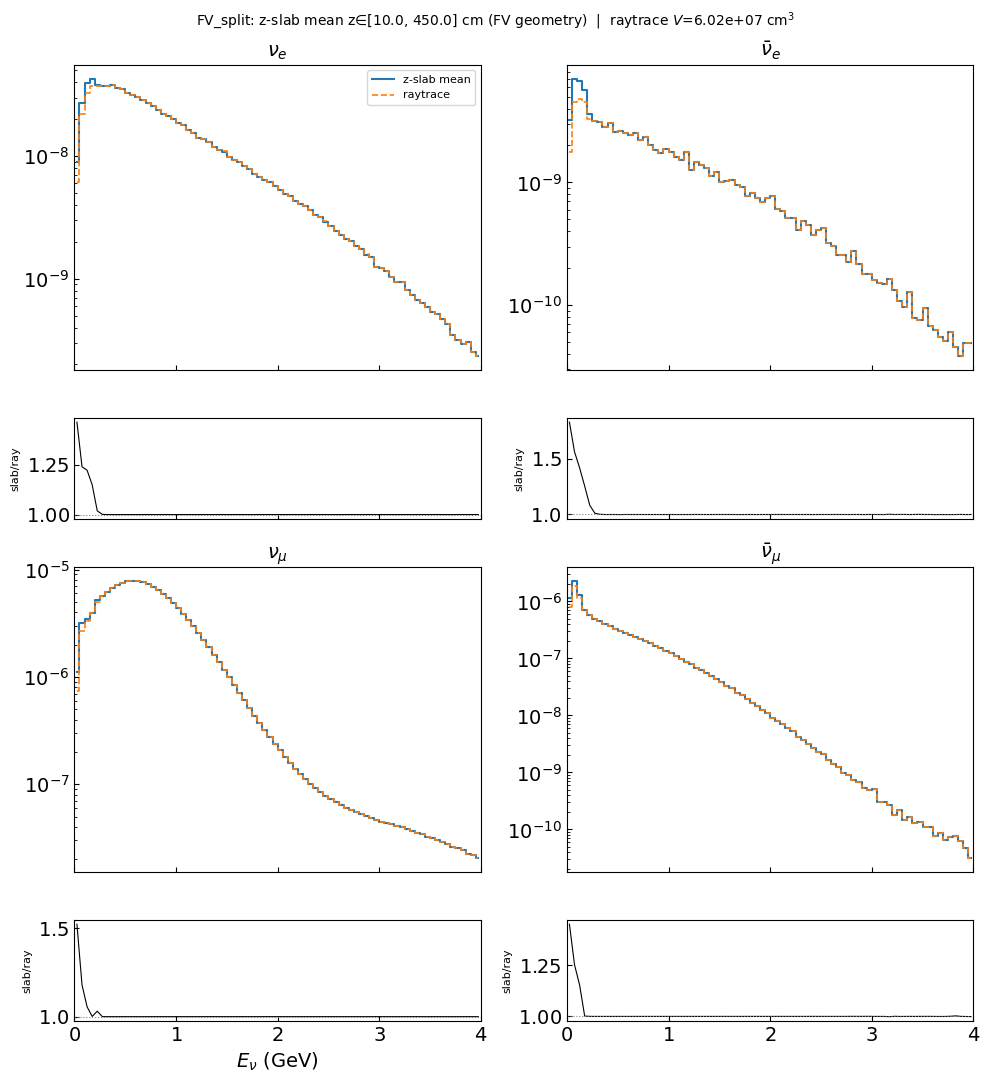

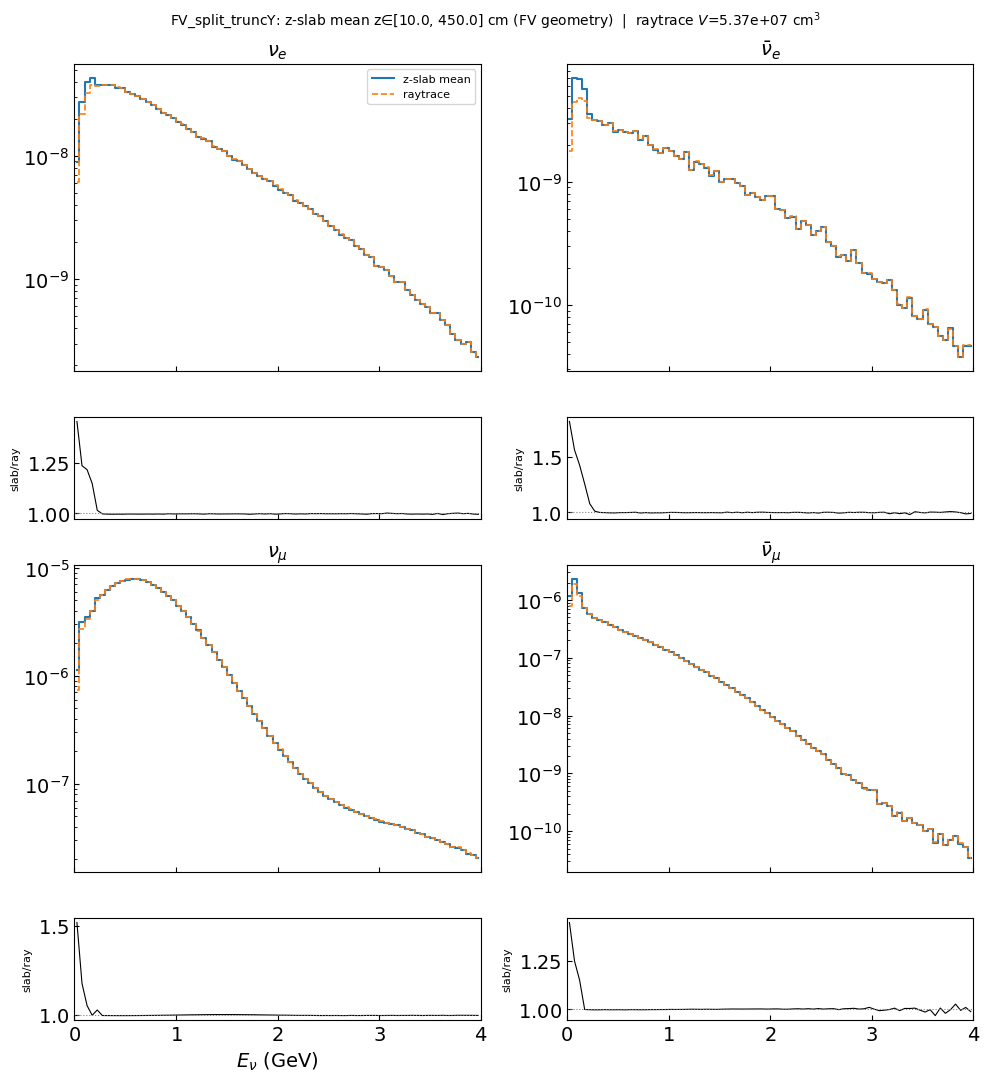

In [5]:
bins = slab["bins"]


def _volume_title(vkey: str, vol_meta: list[dict]) -> str:
    for d in vol_meta:
        if d.get("raytrace_volume_key") == vkey:
            zr = d.get("z_range_cm", [10, 450])
            return f"{vkey}: z-slab mean z∈[{zr[0]}, {zr[1]}] cm (FV geometry)"
    return RAYTRACE_VOLUME_LABEL.get(vkey, vkey)


for iv, vkey in enumerate(slab["vol_keys"]):
    v_cm3 = float(ray["vol_cm3"][iv]) if ray["vol_cm3"] is not None else np.nan
    fig, axes = plt.subplots(
        4, 2, figsize=(10, 11), sharex=True, gridspec_kw={"height_ratios": [3, 1, 3, 1]}
    )
    for iflav, flav in enumerate(FLAVORS):
        r, c = (iflav // 2) * 2, iflav % 2
        ax, ax_ratio = axes[r, c], axes[r + 1, c]
        ps, pr = slab["phi"][iv, iflav], ray["phi"][iv, iflav]
        ax.step(bins, ps, where="mid", color="C0", lw=1.5, label="z-slab mean")
        ax.step(bins, pr, where="mid", color="C1", ls="--", lw=1.2, label="raytrace")
        ratio = np.where(pr > 0, ps / pr, np.nan)
        ax_ratio.plot(bins, ratio, color="k", lw=0.8)
        ax_ratio.axhline(1.0, color="0.5", ls=":", lw=0.8)
        ax_ratio.set_ylabel("slab/ray", fontsize=8)
        ax.set_title(FLAVOR_LATEX[flav])
        ax.set_yscale("log")
        ax.set_xlim(0, 4)
        ax.tick_params(labelbottom=False)
        if iflav == 0:
            ax.legend(fontsize=8)
    axes[-1, 0].set_xlabel(r"$E_\nu$ (GeV)")
    title = _volume_title(vkey, slab["vol_meta"])
    if np.isfinite(v_cm3):
        title += f"  |  raytrace $V$={v_cm3:.3g} cm$^3$"
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    plt.show()


## Integrated flux


In [6]:
print(f"{'volume':18s} {'flavor':8s} {'∫ slab':>12s} {'∫ ray':>12s} {'∫ slab/∫ ray':>14s}")
for iv, vkey in enumerate(slab["vol_keys"]):
    for iflav, flav in enumerate(FLAVORS):
        is_ = float(np.sum(slab["phi"][iv, iflav]))
        ir = float(np.sum(ray["phi"][iv, iflav]))
        print(f"{vkey:18s} {flav:8s} {is_:12.6e} {ir:12.6e} {is_/max(ir,1e-30):14.4f}")


volume             flavor         ∫ slab        ∫ ray   ∫ slab/∫ ray
FV_split           nue      8.965342e-07 8.751650e-07         1.0244
FV_split           nuebar   9.575444e-08 8.835755e-08         1.0837
FV_split           numu     1.516759e-04 1.504898e-04         1.0079
FV_split           numubar  1.135283e-05 1.034993e-05         1.0969
FV_split_truncY    nue      8.984884e-07 8.795415e-07         1.0215
FV_split_truncY    nuebar   9.588835e-08 8.867299e-08         1.0814
FV_split_truncY    numu     1.523463e-04 1.514958e-04         1.0056
FV_split_truncY    numubar  1.136998e-05 1.039843e-05         1.0934


## Z-step convergence (batch slab configs)

Uses `flux_density_mean_cvwf` from `slab_zconfig_flux_histograms.npz` (FV geometry at each
$z$ plane, same boxes as raytrace). Each config is a uniform $z$ grid from
`gsimple_batch.py --slab-z-ns`.


In [7]:
zcfg = np.load(SLAB_ZCONFIG_NPZ, allow_pickle=True)
config_keys = [str(k) for k in zcfg["slab_config_keys"]]
vol_keys = [str(k) for k in zcfg["compare_volume_keys"]]
phi_cvwf = zcfg["flux_density_mean_cvwf"]
dz_cm = np.asarray(zcfg["slab_config_dz_cm"], dtype=float)
n_z_arr = np.asarray(zcfg["slab_config_n_z"], dtype=int)
batch_def = np.asarray(zcfg["slab_config_batch_default"], dtype=bool)
bins = np.asarray(zcfg["BIN_CENTERS"])

if SLAB_ZCONFIG_META.is_file():
    meta_z = json.loads(SLAB_ZCONFIG_META.read_text())
    print("slab configs from meta:", [d["key"] for d in meta_z["slab_config_definitions"]])

sweep_results = []
for icfg, ck in enumerate(config_keys):
    for iv, vkey in enumerate(vol_keys):
        for iflav, flav in enumerate(FLAVORS):
            ps = phi_cvwf[icfg, iv, iflav]
            pr = ray["phi"][iv, iflav]
            ratio = np.where(pr > 0, ps / pr, np.nan)
            valid = np.isfinite(ratio) & (pr > 0)
            med = float(np.nanmedian(ratio[valid])) if np.any(valid) else np.nan
            sweep_results.append(
                {
                    "config_key": ck,
                    "n_z": int(n_z_arr[icfg]),
                    "dz_cm": float(dz_cm[icfg]),
                    "batch_default": bool(batch_def[icfg]),
                    "volume": vkey,
                    "flavor": flav,
                    "median_slab_over_ray": med,
                    "phi_slab": ps,
                    "phi_ray": pr,
                }
            )
print(f"{len(sweep_results)} rows  |  configs: {config_keys}")

# Detect legacy slab npz (rectangular-window proxy before FV-geometry update)
if meta_z and meta_z.get("compare_volume_definitions"):
    legacy = any("window_key" in d for d in meta_z["compare_volume_definitions"])
    if legacy:
        print(
            "WARNING: slab meta still has window_key entries — re-run gsimple_batch.py "
            "for FV-matched slab geometry."
        )


slab configs from meta: ['z10_450_n5', 'z10_450_n11', 'z10_450_n21', 'z10_450_n26', 'z10_450_n51', 'z10_450_n101', 'z10_450_n201', 'z0_500_n26_batch']
64 rows  |  configs: ['z10_450_n5', 'z10_450_n11', 'z10_450_n21', 'z10_450_n26', 'z10_450_n51', 'z10_450_n101', 'z10_450_n201', 'z0_500_n26_batch']


### Convergence vs $\Delta z$


FV_split / numu
config                   n_z    dz_cm  median slab/ray
z10_450_n5                 5   110.00           1.0000
z10_450_n11               11    44.00           0.9999
z10_450_n21               21    22.00           0.9999
z10_450_n26               26    17.60           0.9999
z10_450_n51               51     8.80           0.9999
z10_450_n101             101     4.40           0.9998
z10_450_n201             201     2.20           0.9998
z0_500_n26_batch          26    20.00           0.9998

FV_split_truncY / numu
config                   n_z    dz_cm  median slab/ray
z10_450_n5                 5   110.00           0.9974
z10_450_n11               11    44.00           0.9974
z10_450_n21               21    22.00           0.9975
z10_450_n26               26    17.60           0.9974
z10_450_n51               51     8.80           0.9974
z10_450_n101             101     4.40           0.9974
z10_450_n201             201     2.20           0.9974
z0_500_n26_batch         

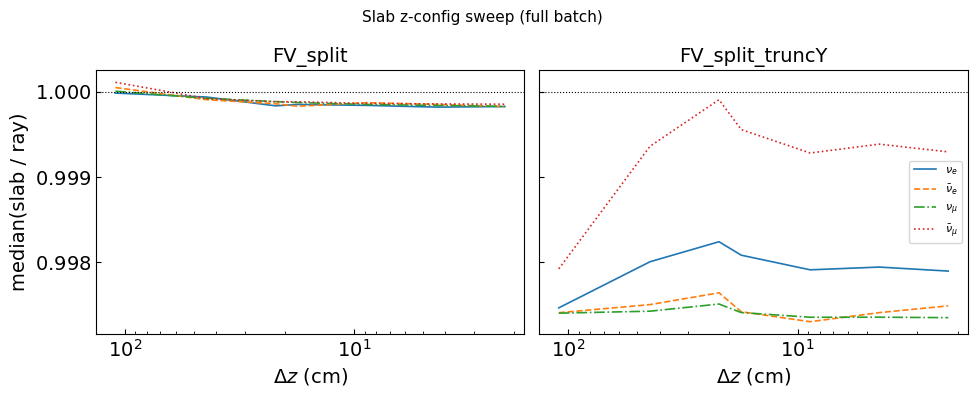

In [8]:
def _sweep_table(volume: str, flavor: str = "numu"):
    rows = sorted(
        [r for r in sweep_results if r["volume"] == volume and r["flavor"] == flavor],
        key=lambda r: (r["batch_default"], -r["dz_cm"]),
    )
    print(f"{volume} / {flavor}")
    print(f"{'config':22s} {'n_z':>5s} {'dz_cm':>8s} {'median slab/ray':>16s}")
    for r in rows:
        print(
            f"{r['config_key']:22s} {r['n_z']:5d} {r['dz_cm']:8.2f} {r['median_slab_over_ray']:16.4f}"
        )


for vkey in vol_keys:
    _sweep_table(vkey, "numu")
    print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, vkey in zip(axes, vol_keys):
    for flav, ls, color in zip(FLAVORS, ["-", "--", "-.", ":"], ["C0", "C1", "C2", "C3"]):
        pts = sorted(
            [r for r in sweep_results if r["volume"] == vkey and r["flavor"] == flav and not r["batch_default"]],
            key=lambda r: r["dz_cm"],
            reverse=True,
        )
        if not pts:
            continue
        ax.plot([r["dz_cm"] for r in pts], [r["median_slab_over_ray"] for r in pts], ls=ls, color=color, lw=1.2, label=FLAVOR_LATEX[flav])
    ax.axhline(1.0, color="k", ls=":", lw=0.8)
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel(r"$\Delta z$ (cm)")
    ax.set_title(vkey)
axes[0].set_ylabel("median(slab / ray)")
axes[1].legend(fontsize=8)
fig.suptitle("Slab z-config sweep (full batch)", fontsize=11)
fig.tight_layout()
plt.show()


### Spectra: selected slab configs vs raytrace ($\nu_\mu$)


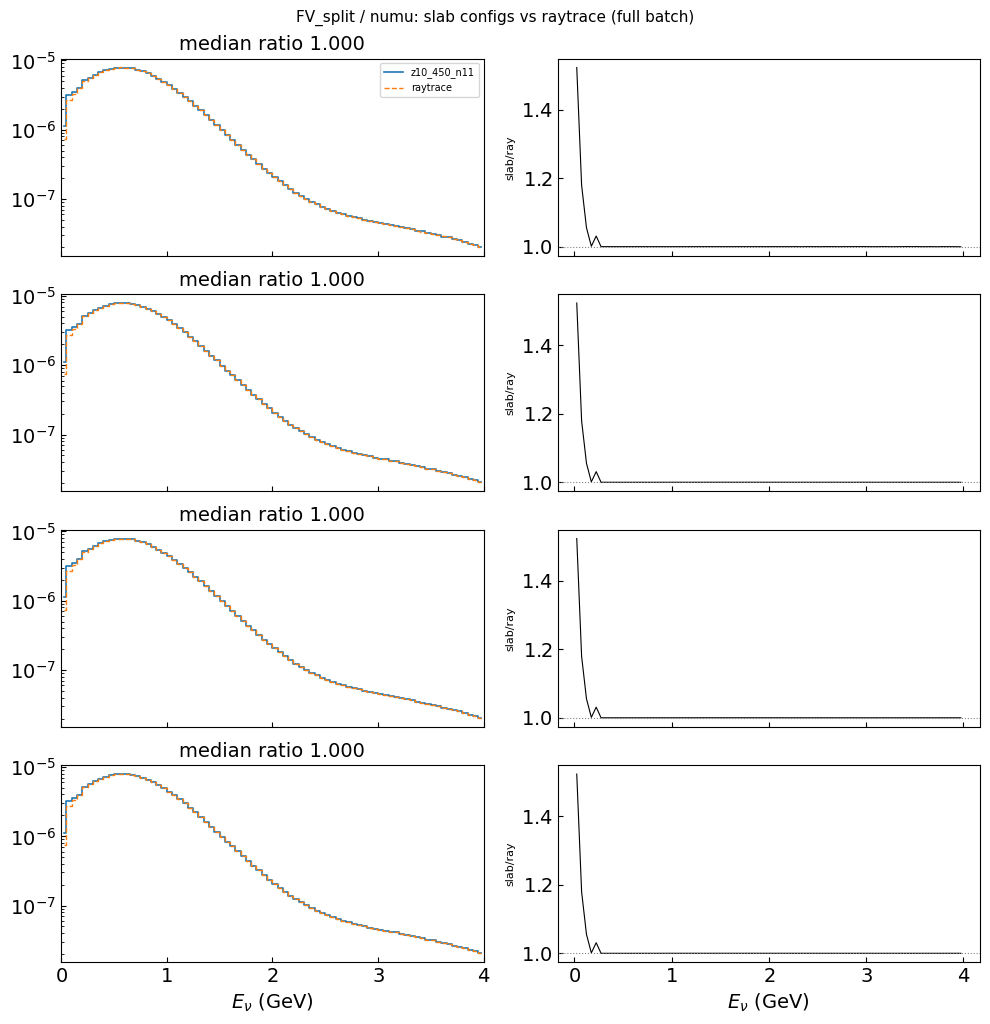

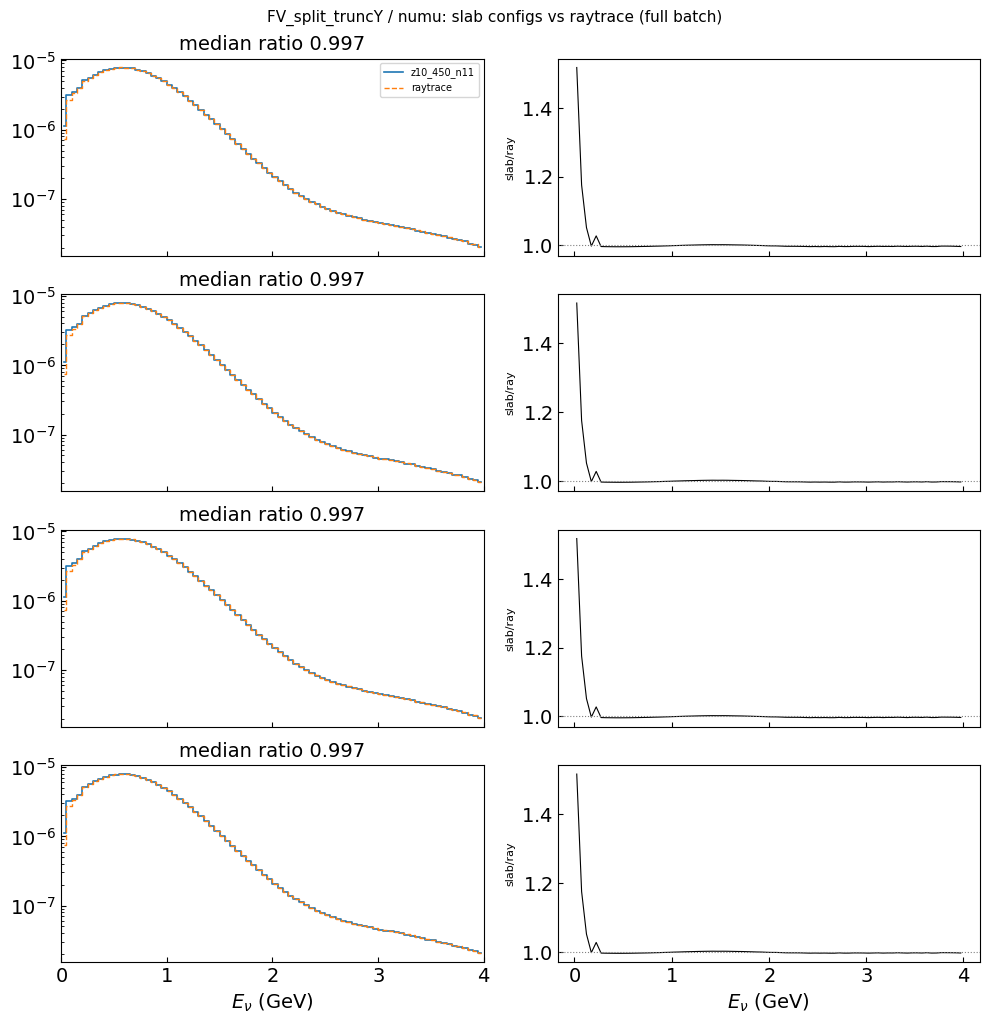

In [9]:
def _pick_sweep(vkey, flav, *, config_key=None, batch_default=False):
    for r in sweep_results:
        if r["volume"] != vkey or r["flavor"] != flav:
            continue
        if batch_default and r["batch_default"]:
            return r
        if config_key and r["config_key"] == config_key:
            return r
    return None


OVERLAY_CONFIG_KEYS = ["z10_450_n11", "z10_450_n51", "z0_500_n26_batch", "z10_450_n201"]
SWEEP_FLAVOR = "numu"
iflav = FLAVORS.index(SWEEP_FLAVOR)

for vkey in vol_keys:
    iv = vol_keys.index(vkey)
    phi_ray = ray["phi"][iv, iflav]
    nrows = len(OVERLAY_CONFIG_KEYS)
    fig, axes = plt.subplots(nrows, 2, figsize=(10, 2.6 * nrows), sharex="col")
    if nrows == 1:
        axes = axes[np.newaxis, :]
    for i, ck in enumerate(OVERLAY_CONFIG_KEYS):
        r = _pick_sweep(vkey, SWEEP_FLAVOR, config_key=ck)
        if r is None:
            print(f"skip {ck} for {vkey}")
            continue
        ps, pr = r["phi_slab"], phi_ray
        ax, axr = axes[i, 0], axes[i, 1]
        ax.step(bins, ps, where="mid", color="C0", lw=1.2, label=ck)
        ax.step(bins, pr, where="mid", color="C1", ls="--", lw=1.0, label="raytrace")
        ratio = np.where(pr > 0, ps / pr, np.nan)
        axr.plot(bins, ratio, color="k", lw=0.8)
        axr.axhline(1.0, color="0.5", ls=":", lw=0.8)
        axr.set_ylabel("slab/ray", fontsize=8)
        ax.set_yscale("log")
        ax.set_xlim(0, 4)
        ax.set_title(f"median ratio {r['median_slab_over_ray']:.3f}")
        if i == 0:
            ax.legend(fontsize=7)
    axes[-1, 0].set_xlabel(r"$E_\nu$ (GeV)")
    axes[-1, 1].set_xlabel(r"$E_\nu$ (GeV)")
    fig.suptitle(f"{vkey} / {SWEEP_FLAVOR}: slab configs vs raytrace (full batch)", fontsize=11)
    fig.tight_layout()
    plt.show()
